# Mạng Nơ-ron Hồi quy (RNN)

## 1. Giới thiệu về RNN

RNN là một loại mạng nơ-ron được thiết kế để xử lý *dữ liệu tuần tự* (sequential data) — như chuỗi thời gian, văn bản, hoặc âm thanh. Điểm đặc biệt của RNN là khả năng "ghi nhớ" thông tin từ các bước trước đó nhờ một vòng lặp ngầm trong kiến trúc.

### Tại sao cần RNN?

Hãy thử nghĩ: nếu mình muốn dự đoán từ tiếp theo trong câu "Tôi thích ăn ___", thì rõ ràng câu trả lời phụ thuộc vào các từ trước đó. Một mạng feedforward (ANN) thông thường nhìn từng input độc lập, nó không có cơ chế nào để "nhớ" rằng vừa nãy đã thấy chữ "thích". RNN giải quyết bằng cách mang theo một **trạng thái ẩn** $h_t$ qua các bước thời gian, đóng vai trò như bộ nhớ ngắn hạn của mạng.

### Một số ứng dụng

- Dự đoán chuỗi thời gian: giá cổ phiếu, nhiệt độ, lượng khách.
- Xử lý ngôn ngữ tự nhiên: dịch máy, sinh văn bản, gán nhãn từ loại.
- Nhận diện giọng nói, tổng hợp tiếng nói.

## 2. Cấu trúc của RNN

Tại mỗi bước thời gian $t$, RNN có ba đại lượng:

- **Đầu vào** $x_t$
- **Trạng thái ẩn** $h_t$ — bộ nhớ tích luỹ
- **Đầu ra** $y_t$

Trạng thái ẩn $h_t$ vừa được sinh ra từ $h_{t-1}$ và $x_t$, vừa là "đầu vào" cho bước kế tiếp $h_{t+1}$. Cùng một bộ trọng số được dùng cho mọi bước thời gian — đây gọi là **chia sẻ trọng số** (weight sharing), điểm tinh tế giúp RNN xử lý chuỗi có độ dài bất kỳ với số tham số cố định.

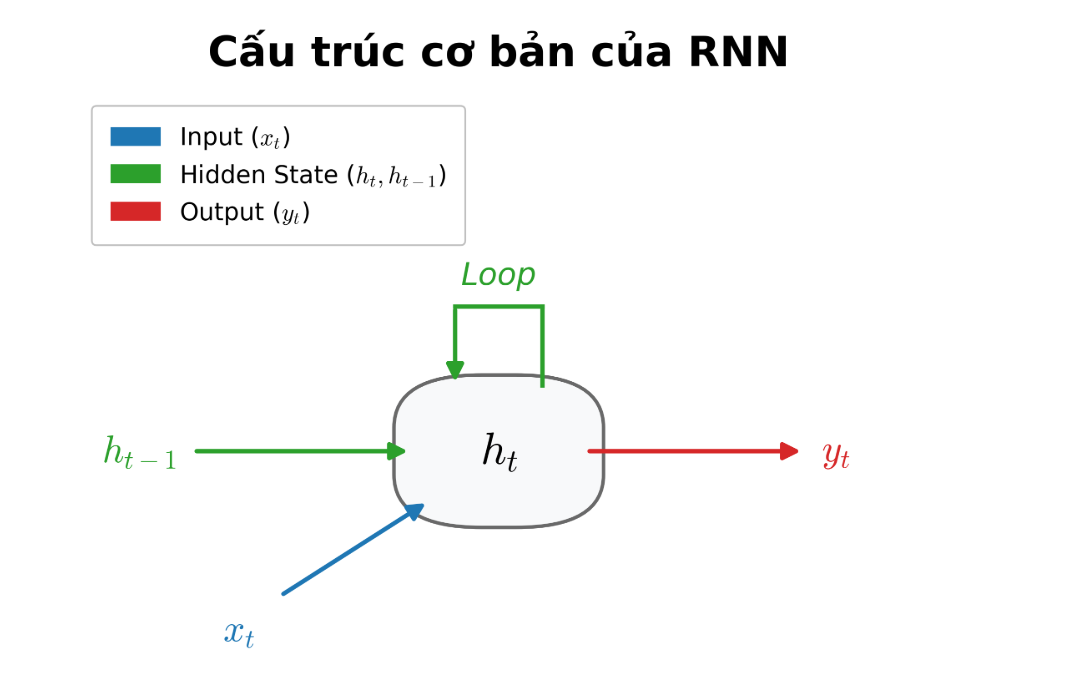


## 3. Công thức toán học của RNN

Tại mỗi thời điểm $t$, mô hình nhận đầu vào $x_t$, kết hợp với trạng thái ẩn từ bước trước $h_{t-1}$, rồi tạo ra trạng thái ẩn mới $h_t$. Từ trạng thái ẩn này, mô hình tính đầu ra $y_t$.

### 3.1. Công thức tính trạng thái ẩn

$$
h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

Trong đó:
- $x_t$: vector đầu vào tại thời điểm $t$
- $h_{t-1}$: trạng thái ẩn của bước liền trước
- $W_{xh}$: ma trận trọng số nối đầu vào với trạng thái ẩn
- $W_{hh}$: ma trận trọng số hồi quy (recurrent), nối $h_{t-1}$ với $h_t$
- $b_h$: bias của tầng ẩn
- $f$: hàm kích hoạt phi tuyến, thường là $\tanh$

Có thể đọc công thức theo nghĩa: trạng thái ẩn mới = một sự pha trộn giữa thông tin hiện tại ($x_t$) và thông tin quá khứ ($h_{t-1}$), rồi nén qua phi tuyến.

#### Ví dụ minh hoạ bằng số

Giả sử:
$$x_t = [0.5,\ 0.1]^T, \quad h_{t-1} = [0.2,\ 0.3]^T$$
$$W_{xh} = \begin{bmatrix}0.1 & 0.2\\ 0.3 & 0.4\end{bmatrix}, \quad W_{hh} = \begin{bmatrix}0.5 & 0.6\\ 0.7 & 0.8\end{bmatrix}, \quad b_h = [0.1,\ 0.2]^T$$

**Bước 1.** Phần đóng góp của đầu vào:
$$W_{xh}x_t = \begin{bmatrix}0.1\cdot 0.5 + 0.2\cdot 0.1\\ 0.3\cdot 0.5 + 0.4\cdot 0.1\end{bmatrix} = \begin{bmatrix}0.07\\ 0.19\end{bmatrix}$$

**Bước 2.** Phần đóng góp của quá khứ:
$$W_{hh}h_{t-1} = \begin{bmatrix}0.5\cdot 0.2 + 0.6\cdot 0.3\\ 0.7\cdot 0.2 + 0.8\cdot 0.3\end{bmatrix} = \begin{bmatrix}0.28\\ 0.38\end{bmatrix}$$

**Bước 3.** Cộng cả hai và bias:
$$\begin{bmatrix}0.07\\ 0.19\end{bmatrix} + \begin{bmatrix}0.28\\ 0.38\end{bmatrix} + \begin{bmatrix}0.1\\ 0.2\end{bmatrix} = \begin{bmatrix}0.45\\ 0.77\end{bmatrix}$$

**Bước 4.** Áp dụng $\tanh$:
$$h_t = \tanh([0.45,\ 0.77]^T) \approx [0.422,\ 0.647]^T$$

### 3.2. Công thức tính đầu ra

$$
y_t = g(W_{hy}h_t + b_y)
$$

Hàm $g$ tuỳ bài toán:
- **Sigmoid** cho phân loại nhị phân.
- **Softmax** cho phân loại nhiều lớp.
- **Không hàm kích hoạt** (identity) cho hồi quy.

#### Tiếp nối ví dụ

Với $W_{hy} = [0.9,\ 0.8]$ và $b_y = 0.05$:
$$W_{hy}h_t + b_y = 0.9\cdot 0.422 + 0.8\cdot 0.647 + 0.05 \approx 0.947$$
$$y_t = \sigma(0.947) = \frac{1}{1 + e^{-0.947}} \approx 0.720$$

## 4. Huấn luyện RNN — Backpropagation Through Time (BPTT)

RNN được huấn luyện bằng thuật toán **lan truyền ngược qua thời gian**. Ý tưởng: "trải" mạng theo từng bước thời gian thành một mạng phẳng dài $T$ tầng, rồi chạy backprop bình thường — chỉ khác là tất cả các "tầng" này dùng *chung một bộ trọng số*.

Tổng loss trên cả chuỗi:
$$
L = \sum_{t=1}^{T} L_t
$$

### Vì sao gradient biến mất? Một chứng minh ngắn

Khi tính $\partial L_t / \partial W_{hh}$, đạo hàm phải đi qua chuỗi các trạng thái ẩn từ $h_t$ về $h_1$:

$$
\frac{\partial L_t}{\partial W_{hh}} = \sum_{k=1}^{t} \frac{\partial L_t}{\partial h_t}\Big(\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}\Big)\frac{\partial h_k}{\partial W_{hh}}
$$

Cái tích $\prod \partial h_j/\partial h_{j-1}$ chính là điểm chết người. Mỗi nhân tử có dạng $\text{diag}(f'(\cdot)) \cdot W_{hh}$. Với $\tanh$, $f'$ luôn $\le 1$. Nếu giá trị riêng (eigenvalue) lớn nhất của $W_{hh}$ < 1, tích này **co lại theo cấp số nhân** khi $t-k$ lớn → gradient từ các bước xa gần như bằng 0. Đây là **vanishing gradient**.

Ngược lại, nếu eigenvalue > 1 thì tích bùng nổ → **exploding gradient** (xử lý dễ hơn nhiều: dùng `torch.nn.utils.clip_grad_norm_`).

Hệ quả thực tế: RNN cơ bản không học được phụ thuộc xa quá ~10-20 bước. Đó là động lực cho LSTM/GRU (bài sau).

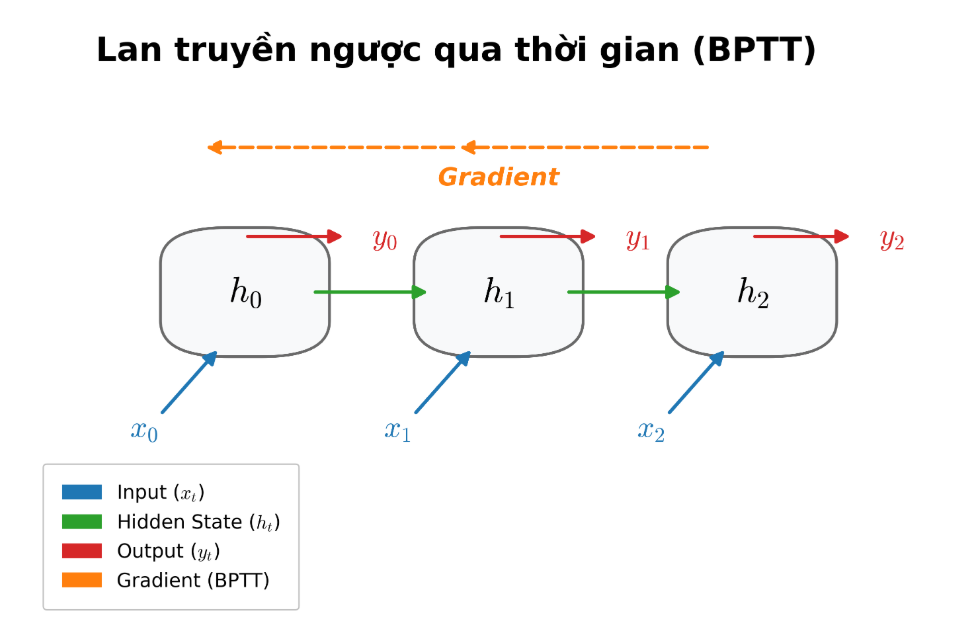


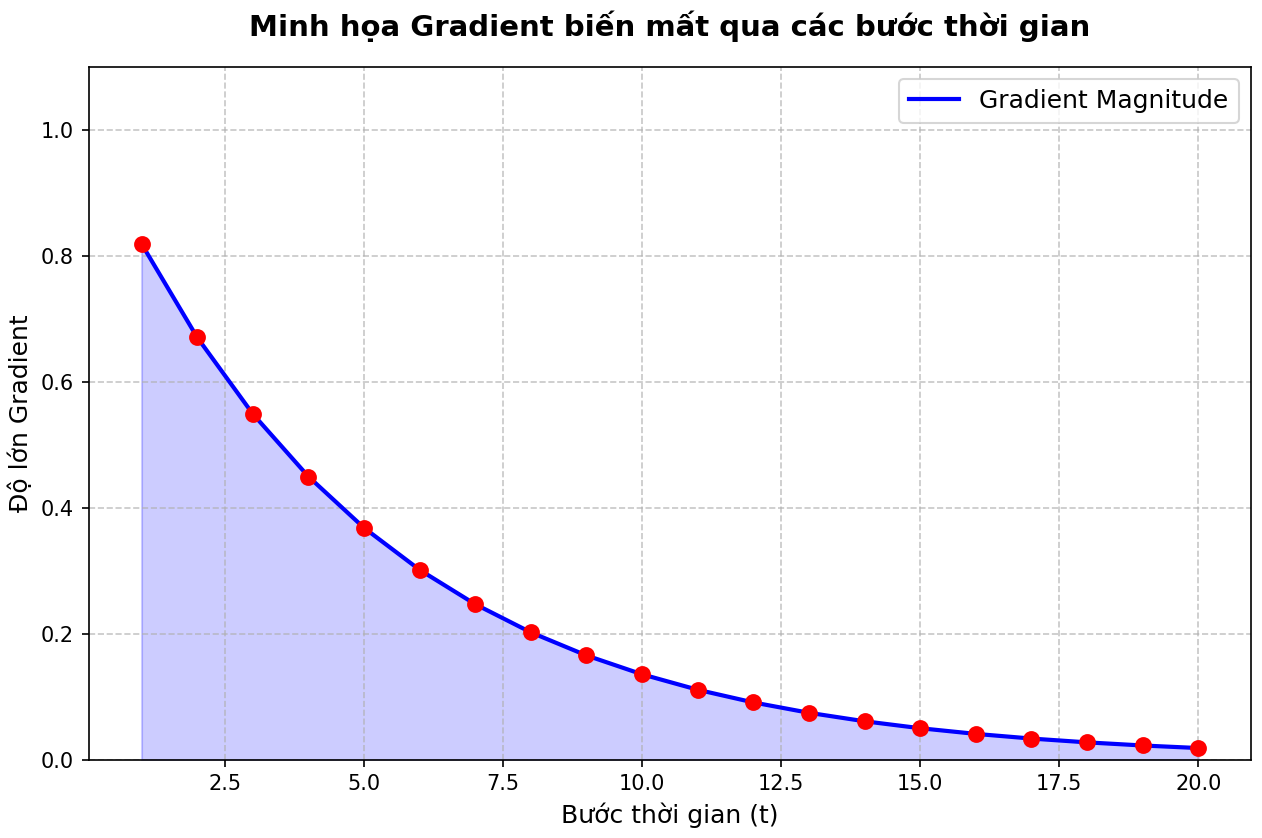


## 5. Ví dụ: dự đoán từ tiếp theo

Cho từ điển 3 từ: `["Tôi", "thích", "học"]`, biểu diễn one-hot là `[1,0,0]`, `[0,1,0]`, `[0,0,1]`.

Đưa lần lượt "Tôi" rồi "thích" vào RNN, ở bước thứ 2 mạng sinh ra một vector xác suất sau softmax:
$$y_2 = [0.1,\ 0.2,\ 0.7]$$

Vị trí lớn nhất là chỉ số 2 → từ "học". Mạng đoán câu tiếp theo là **"học"**. Điểm hay: dự đoán không chỉ dựa vào "thích" hiện tại, mà còn nhờ trạng thái ẩn đã "nhớ" được "Tôi" trước đó.

## 6. So sánh RNN với Feedforward NN

| **RNN** | **Feedforward NN** |
|---|---|
| Xử lý dữ liệu tuần tự, chiều dài bất kỳ | Đầu vào kích thước cố định, độc lập từng mẫu |
| Có trạng thái ẩn $h_t$ — bộ nhớ ngắn hạn | Không có bộ nhớ |
| Trọng số chia sẻ qua thời gian | Mỗi tầng có bộ trọng số riêng |
| Dễ vanishing gradient với chuỗi dài | Không có vấn đề này (nhưng có vấn đề khác như overfitting) |

# BÀI THỰC HÀNH: DỰ BÁO SÓNG SIN VỚI RNN

Ta sẽ dùng RNN để học dạng sóng sin có nhiễu, rồi dự đoán giá trị tiếp theo. Bài này có hai cách đánh giá khác nhau — và đây là chỗ dễ nhầm:

1. **One-step-ahead** (đánh giá chuẩn): mỗi bước dự đoán một giá trị, *dùng dữ liệu thật* làm input. Đây là metric đáng tin cậy.
2. **Rollout / Auto-regressive** (dự báo dài hạn): chỉ cho input ban đầu, sau đó *dùng output của chính mình* làm input cho bước tiếp theo. Sai số tích luỹ rất nhanh — model sẽ trôi (drift) theo hàm sin tưởng tượng của nó.

Cả hai đều có ý nghĩa, nhưng phải báo cáo riêng từng loại.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
# Giới hạn số thread để notebook chạy ổn định trên máy yếu.
torch.set_num_threads(1)


## Bước 1. Chuẩn bị dữ liệu

Sinh 200 điểm sóng sin có nhiễu, chuẩn hoá về [0, 1], rồi cắt thành các "cửa sổ trượt" độ dài 10. Mỗi mẫu huấn luyện sẽ có dạng: nhìn 10 giá trị quá khứ, đoán giá trị thứ 11.

X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


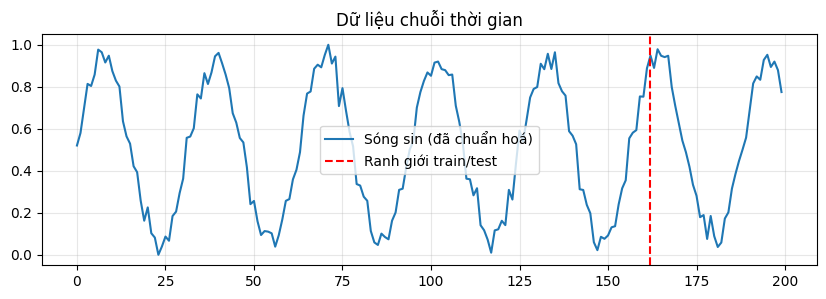

In [2]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

## Bước 2. Định nghĩa mô hình RNN

Một lớp `nn.RNN` đơn giản với `hidden_size = 20`, theo sau là một lớp Linear để biến trạng thái ẩn cuối cùng thành một số (giá trị dự đoán).

`batch_first=True` nghĩa là input có shape `(batch, seq_len, input_size)` — dễ đọc hơn cho người mới.

In [3]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


## Bước 3. Vòng lặp huấn luyện — phải duyệt qua tất cả batch

Lưu ý quan trọng: ở mỗi epoch ta phải duyệt qua **toàn bộ** tập train, chia thành nhiều batch. Cách dễ nhất là dùng `DataLoader`. Nhiều bạn lần đầu chỉ lấy ngẫu nhiên 1 batch mỗi epoch, dẫn đến model train cực kỳ thiếu hiệu quả (chỉ thấy được 16/152 mẫu mỗi epoch).

In [4]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


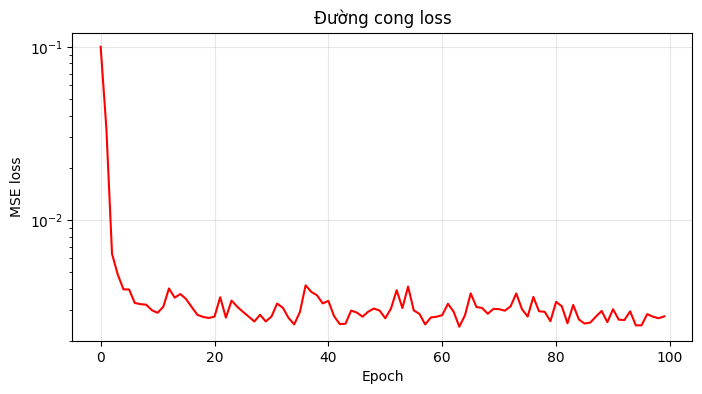

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

## Bước 4. Đánh giá one-step-ahead (đáng tin cậy)

Mỗi mẫu test có 10 giá trị quá khứ thật → dự đoán 1 giá trị tiếp theo. Ta dùng `MSE` và `MAE` làm metric.

In [6]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


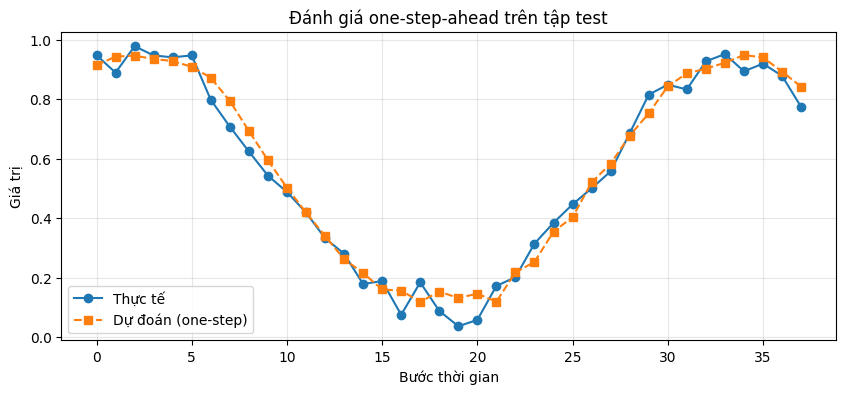

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Bước 5. Dự báo dài hạn (rollout) — và lý do nó trôi

Bây giờ ta thử cho model một cửa sổ ban đầu, sau đó *liên tục đẩy output của model trở lại làm input*. Đây là kịch bản nếu ta muốn dự báo nhiều bước về tương lai mà không có dữ liệu thật.

Sai số mỗi bước rất nhỏ, nhưng tích luỹ qua hàng chục bước — model sẽ dần dần "lệch tông" so với sóng thật. Đây là minh hoạ kinh điển của vấn đề **error accumulation** trong dự báo chuỗi.

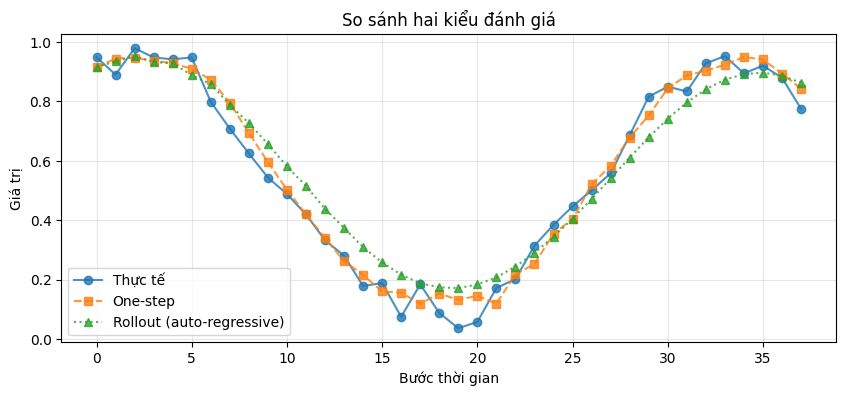

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [8]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

## Tổng kết bài lab

- RNN học được pattern tuần hoàn của sóng sin tốt khi đánh giá one-step.
- Khi rollout dài, sai số tích luỹ → model trôi. Đây không phải lỗi code, mà là bản chất của dự báo auto-regressive.
- Phải so sánh với baseline naive (gán giá trị cuối) để đảm bảo model thật sự *học được gì*, chứ không chỉ đoán "y hệt giá trị vừa rồi".
- Vòng lặp train phải duyệt toàn bộ batch mỗi epoch — không lấy ngẫu nhiên 1 batch.

# BÀI TẬP VỀ NHÀ

## Bài tập 1: Dự báo chuỗi thời gian đa biến

### Mô tả bài toán
Trong buổi học trên lớp, ta đã làm bài dự báo chuỗi thời gian đơn biến (chỉ một sóng sin). Bây giờ em sẽ làm việc với **dữ liệu đa biến** — gồm nhiều đặc trưng đầu vào, dự đoán một biến mục tiêu.

### Mục tiêu
- Tự xử lý dữ liệu chuỗi thời gian đa biến.
- Mở rộng kiến trúc RNN để nhận `input_size > 1`.
- So sánh tác động của các siêu tham số tới hiệu năng.

### Dữ liệu (đã sinh sẵn ở cell tiếp theo)
- `feature_1`: dạng sin
- `feature_2`: dạng cos
- `feature_3`: xu hướng tăng có nhiễu
- `target`: tổ hợp tuyến tính của ba đặc trưng + nhiễu

### Yêu cầu

**Phần A — Tiền xử lý**
- Chuẩn hoá tất cả các cột về [0, 1] (lưu ý: chỉ fit scaler trên train, sau đó áp dụng cho val/test — tránh data leakage).
- Tạo cửa sổ trượt `seq_length = 20`.
- Chia 70% train / 15% val / 15% test theo thứ tự thời gian (KHÔNG shuffle vì là chuỗi thời gian).

**Phần B — Mô hình**
- `input_size = 3`, `hidden_size = 32`, `output_size = 1`.
- Loss `MSELoss`, optimizer Adam, 150 epoch.
- Lưu cả train_loss và val_loss qua từng epoch.

**Phần C — Đánh giá**
- Trên tập test: tính MSE, MAE.
- Vẽ biểu đồ so sánh giá trị thật và giá trị dự đoán.
- So sánh với baseline naive (giá trị tiếp theo = giá trị cuối cùng).

**Phần D — Phân tích nâng cao**
- Thử ít nhất 3 giá trị `seq_length` (10, 20, 30): MSE thay đổi thế nào?
- Thử `hidden_size ∈ {16, 32, 64}`: model nào underfit, model nào overfit?
- Thử thêm dropout: `nn.RNN(..., dropout=0.2, num_layers=2)`. Quan sát train_loss và val_loss.
- Viết một đoạn nhận xét khoảng 5-10 dòng về những gì em quan sát được.

### Gợi ý
- Cẩn thận khi reshape: `X` phải có shape `(num_samples, seq_length, input_size)`.
- Khi vẽ kết quả, nhớ "un-normalize" lại nếu muốn xem giá trị gốc.

**Hạn nộp:** 28/03/2026

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


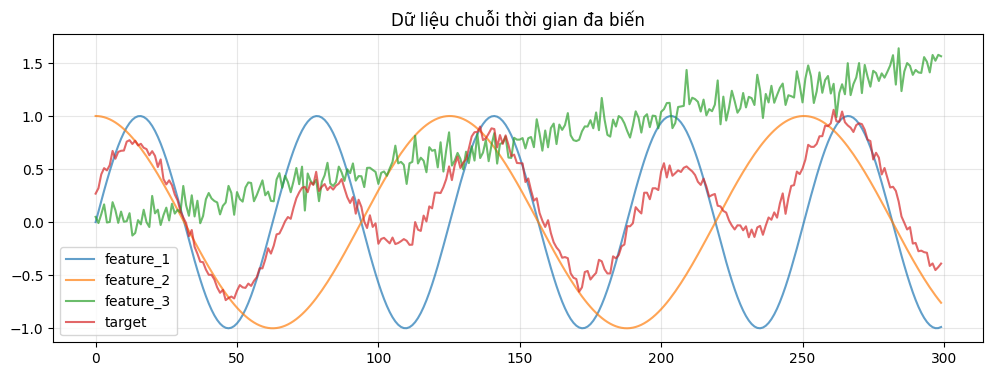

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()

In [11]:
# Phần A — tiền xử lý dữ liệu đa biến

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

feature_cols = ['feature_1', 'feature_2', 'feature_3']
target_col = 'target'

# Chia theo thời gian trên dữ liệu gốc: 70% train, 15% val, 15% test.
n_total = len(df)
train_end = int(0.70 * n_total)
val_end = int(0.85 * n_total)

# Fit min-max scaler CHỈ trên train để tránh data leakage.
train_df = df.iloc[:train_end]
col_min = train_df.min()
col_max = train_df.max()
col_range = (col_max - col_min).replace(0, 1)

df_scaled = (df - col_min) / col_range

def tao_cua_so_da_bien(df_scaled, seq_length=20):
    X_list, y_list, target_index_list = [], [], []
    features = df_scaled[feature_cols].values.astype(np.float32)
    target_values = df_scaled[target_col].values.astype(np.float32)

    for i in range(len(df_scaled) - seq_length):
        X_list.append(features[i:i + seq_length])
        y_list.append([target_values[i + seq_length]])
        target_index_list.append(i + seq_length)

    X_tensor = torch.tensor(np.array(X_list), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_list), dtype=torch.float32)
    target_indices = np.array(target_index_list)
    return X_tensor, y_tensor, target_indices

seq_length_bt1 = 20
X_all, y_all, target_indices = tao_cua_so_da_bien(df_scaled, seq_length_bt1)

train_mask = target_indices < train_end
val_mask = (target_indices >= train_end) & (target_indices < val_end)
test_mask = target_indices >= val_end

X_train_mv, y_train_mv = X_all[train_mask], y_all[train_mask]
X_val_mv, y_val_mv = X_all[val_mask], y_all[val_mask]
X_test_mv, y_test_mv = X_all[test_mask], y_all[test_mask]

print('Shape X_all:', X_all.shape)
print('Shape y_all:', y_all.shape)
print('Train:', X_train_mv.shape, y_train_mv.shape)
print('Val  :', X_val_mv.shape, y_val_mv.shape)
print('Test :', X_test_mv.shape, y_test_mv.shape)
print('Min/max được fit trên train:')
print(pd.DataFrame({'min': col_min, 'max': col_max}))


Shape X_all: torch.Size([280, 20, 3])
Shape y_all: torch.Size([280, 1])
Train: torch.Size([190, 20, 3]) torch.Size([190, 1])
Val  : torch.Size([45, 20, 3]) torch.Size([45, 1])
Test : torch.Size([45, 20, 3]) torch.Size([45, 1])
Min/max được fit trên train:
                min       max
feature_1 -0.999994  0.999950
feature_2 -0.999978  1.000000
feature_3 -0.126111  1.433768
target    -0.734710  0.900371


Epoch [ 30/150] train_loss=0.00397 val_loss=0.00133


Epoch [ 60/150] train_loss=0.00139 val_loss=0.00247


Epoch [ 90/150] train_loss=0.00114 val_loss=0.00113


Epoch [120/150] train_loss=0.00174 val_loss=0.00239


Epoch [150/150] train_loss=0.00167 val_loss=0.00283


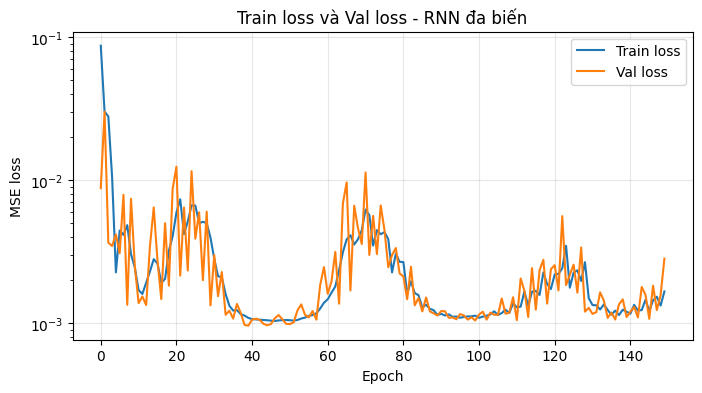

In [ ]:
# Phần B — định nghĩa và train mô hình RNN đa biến

class RNNDaBien(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

def train_rnn_da_bien(seq_length=20, hidden_size=32, dropout=0.0, num_layers=1,
                      num_epochs=150, lr=1e-2, batch_size=16, verbose=False):
    # Tạo lại cửa sổ để có thể thử nhiều seq_length ở Phần D.
    X_all_tmp, y_all_tmp, idx_tmp = tao_cua_so_da_bien(df_scaled, seq_length)
    train_mask_tmp = idx_tmp < train_end
    val_mask_tmp = (idx_tmp >= train_end) & (idx_tmp < val_end)
    test_mask_tmp = idx_tmp >= val_end

    X_train_tmp, y_train_tmp = X_all_tmp[train_mask_tmp], y_all_tmp[train_mask_tmp]
    X_val_tmp, y_val_tmp = X_all_tmp[val_mask_tmp], y_all_tmp[val_mask_tmp]
    X_test_tmp, y_test_tmp = X_all_tmp[test_mask_tmp], y_all_tmp[test_mask_tmp]

    train_loader_tmp = DataLoader(
        TensorDataset(X_train_tmp, y_train_tmp),
        batch_size=batch_size,
        shuffle=False
    )

    model_tmp = RNNDaBien(
        input_size=3,
        hidden_size=hidden_size,
        output_size=1,
        num_layers=num_layers,
        dropout=dropout
    )
    criterion_tmp = nn.MSELoss()
    optimizer_tmp = torch.optim.Adam(model_tmp.parameters(), lr=lr)

    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        model_tmp.train()
        tong_loss, tong_mau = 0.0, 0

        for X_batch, y_batch in train_loader_tmp:
            optimizer_tmp.zero_grad()
            y_pred = model_tmp(X_batch)
            loss = criterion_tmp(y_pred, y_batch)
            loss.backward()
            optimizer_tmp.step()

            tong_loss += loss.item() * X_batch.size(0)
            tong_mau += X_batch.size(0)

        train_loss = tong_loss / tong_mau

        model_tmp.eval()
        with torch.no_grad():
            val_pred = model_tmp(X_val_tmp)
            val_loss = criterion_tmp(val_pred, y_val_tmp).item()

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        if verbose and (epoch + 1) % 30 == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}] train_loss={train_loss:.5f} val_loss={val_loss:.5f}')

    return {
        'model': model_tmp,
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'X_train': X_train_tmp,
        'y_train': y_train_tmp,
        'X_val': X_val_tmp,
        'y_val': y_val_tmp,
        'X_test': X_test_tmp,
        'y_test': y_test_tmp,
        'target_indices': idx_tmp[test_mask_tmp]
    }

ket_qua_bt1 = train_rnn_da_bien(
    seq_length=20,
    hidden_size=32,
    dropout=0.0,
    num_layers=1,
    num_epochs=150,
    verbose=True
)

plt.figure(figsize=(8, 4))
plt.plot(ket_qua_bt1['train_loss'], label='Train loss')
plt.plot(ket_qua_bt1['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Train loss và Val loss - RNN đa biến')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()


RNN đa biến - Test MSE: 0.001649, MAE: 0.031027
Baseline naive - Test MSE: 0.002131, MAE: 0.036170


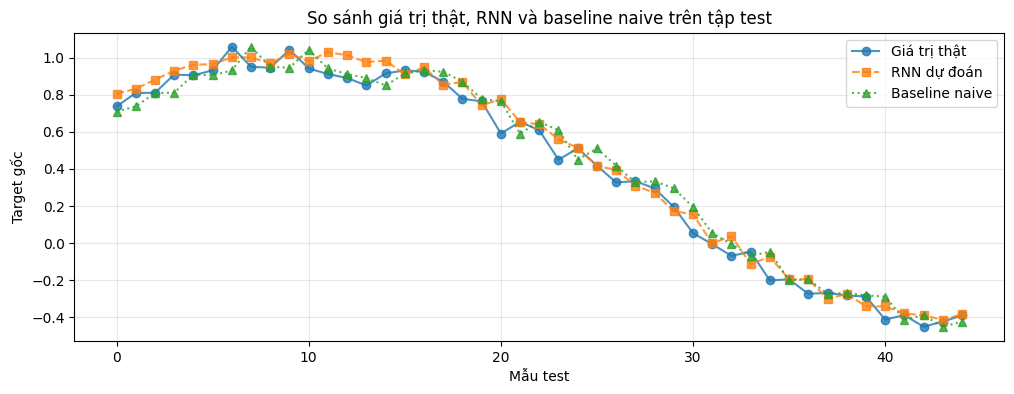

In [ ]:
# Phần C — đánh giá trên tập test và so sánh baseline naive

def unscale_target(values):
    return values * col_range[target_col] + col_min[target_col]

model_mv = ket_qua_bt1['model']
model_mv.eval()

with torch.no_grad():
    pred_test_scaled = model_mv(ket_qua_bt1['X_test']).squeeze().numpy()
    truth_test_scaled = ket_qua_bt1['y_test'].squeeze().numpy()

# Baseline naive: target tiếp theo = target ở thời điểm ngay trước nó.
target_scaled = df_scaled[target_col].values.astype(np.float32)
test_target_indices = ket_qua_bt1['target_indices']
naive_test_scaled = target_scaled[test_target_indices - 1]

mse_rnn = np.mean((pred_test_scaled - truth_test_scaled) ** 2)
mae_rnn = np.mean(np.abs(pred_test_scaled - truth_test_scaled))
mse_naive = np.mean((naive_test_scaled - truth_test_scaled) ** 2)
mae_naive = np.mean(np.abs(naive_test_scaled - truth_test_scaled))

print(f'RNN đa biến - Test MSE: {mse_rnn:.6f}, MAE: {mae_rnn:.6f}')
print(f'Baseline naive - Test MSE: {mse_naive:.6f}, MAE: {mae_naive:.6f}')

# Un-normalize để biểu đồ dễ hiểu hơn theo đơn vị gốc.
pred_test = unscale_target(pred_test_scaled)
truth_test = unscale_target(truth_test_scaled)
naive_test = unscale_target(naive_test_scaled)

plt.figure(figsize=(12, 4))
plt.plot(truth_test, 'o-', label='Giá trị thật', alpha=0.8)
plt.plot(pred_test, 's--', label='RNN dự đoán', alpha=0.8)
plt.plot(naive_test, '^:', label='Baseline naive', alpha=0.8)
plt.xlabel('Mẫu test')
plt.ylabel('Target gốc')
plt.title('So sánh giá trị thật, RNN và baseline naive trên tập test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Kết quả theo seq_length:


,seq_length,test_mse,test_mae,train_loss_cuoi,val_loss_cuoi
0,10,0.002270,0.040059,0.001594,0.001462
1,20,0.001396,0.031342,0.001122,0.001137
2,30,0.092761,0.275380,0.134371,0.019686



Kết quả theo hidden_size:


,hidden_size,test_mse,test_mae,train_loss_cuoi,val_loss_cuoi,gap_val_train
0,16,0.001992,0.034895,0.001801,0.003406,0.001605
1,32,0.001115,0.027392,0.001991,0.001587,-0.000404
2,64,0.002906,0.044222,0.001672,0.001457,-0.000215



Kết quả khi thêm dropout:


,model,test_mse,test_mae,train_loss_cuoi,val_loss_cuoi
0,"RNN 1 layer, dropout=0.0",0.002537,0.039836,0.002379,0.003219
1,"RNN 2 layers, dropout=0.2",0.001819,0.033373,0.003821,0.004368


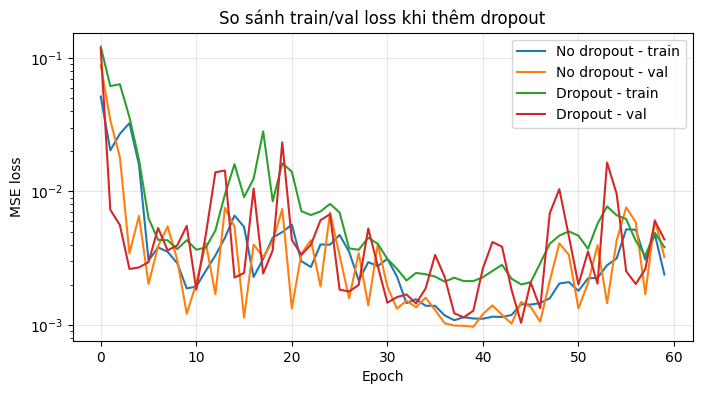


NHẬN XÉT:
1. Với seq_length, giá trị tốt nhất trong lần chạy này là seq_length=20 với test_mse=0.001396.
2. Seq_length quá ngắn có thể thiếu thông tin quá khứ; seq_length quá dài làm mô hình khó học hơn và dễ nhiễu.
3. Với hidden_size, mô hình tốt nhất trong lần chạy này là hidden_size=32 với test_mse=0.001115.
4. hidden_size=32 có train_loss cuối lớn nhất nên có dấu hiệu underfit hơn các cấu hình còn lại.
5. hidden_size=16 có gap val-train lớn nhất nên dễ có dấu hiệu overfit hơn.
6. Dropout làm train_loss thường cao hơn vì mô hình bị regularize trong lúc học.
7. Nếu val_loss giảm hoặc ổn định hơn khi dùng dropout thì dropout có tác dụng chống overfitting.
8. Trong bài này dữ liệu khá đơn giản nên khác biệt giữa các cấu hình có thể không quá lớn.


In [ ]:
# Phần D — phân tích nâng cao: seq_length, hidden_size, dropout

def danh_gia_model_da_bien(ket_qua):
    model_tmp = ket_qua['model']
    model_tmp.eval()
    with torch.no_grad():
        pred = model_tmp(ket_qua['X_test']).squeeze().numpy()
        truth = ket_qua['y_test'].squeeze().numpy()
    mse = np.mean((pred - truth) ** 2)
    mae = np.mean(np.abs(pred - truth))
    return mse, mae

# 1) Thử seq_length = 10, 20, 30
seq_results = []
for seq in [10, 20, 30]:
    kq = train_rnn_da_bien(seq_length=seq, hidden_size=32, num_epochs=60)
    mse, mae = danh_gia_model_da_bien(kq)
    seq_results.append({
        'seq_length': seq,
        'test_mse': mse,
        'test_mae': mae,
        'train_loss_cuoi': kq['train_loss'][-1],
        'val_loss_cuoi': kq['val_loss'][-1]
    })

seq_df = pd.DataFrame(seq_results)
print('Kết quả theo seq_length:')
display(seq_df)

# 2) Thử hidden_size = 16, 32, 64
hidden_results = []
for h in [16, 32, 64]:
    kq = train_rnn_da_bien(seq_length=20, hidden_size=h, num_epochs=60)
    mse, mae = danh_gia_model_da_bien(kq)
    hidden_results.append({
        'hidden_size': h,
        'test_mse': mse,
        'test_mae': mae,
        'train_loss_cuoi': kq['train_loss'][-1],
        'val_loss_cuoi': kq['val_loss'][-1],
        'gap_val_train': kq['val_loss'][-1] - kq['train_loss'][-1]
    })

hidden_df = pd.DataFrame(hidden_results)
print('\nKết quả theo hidden_size:')
display(hidden_df)

# 3) Thử dropout với 2 tầng RNN
kq_khong_dropout = train_rnn_da_bien(seq_length=20, hidden_size=32, num_layers=1, dropout=0.0, num_epochs=60)
kq_dropout = train_rnn_da_bien(seq_length=20, hidden_size=32, num_layers=2, dropout=0.2, num_epochs=60)

mse_khong_dropout, mae_khong_dropout = danh_gia_model_da_bien(kq_khong_dropout)
mse_dropout, mae_dropout = danh_gia_model_da_bien(kq_dropout)

dropout_df = pd.DataFrame([
    {
        'model': 'RNN 1 layer, dropout=0.0',
        'test_mse': mse_khong_dropout,
        'test_mae': mae_khong_dropout,
        'train_loss_cuoi': kq_khong_dropout['train_loss'][-1],
        'val_loss_cuoi': kq_khong_dropout['val_loss'][-1]
    },
    {
        'model': 'RNN 2 layers, dropout=0.2',
        'test_mse': mse_dropout,
        'test_mae': mae_dropout,
        'train_loss_cuoi': kq_dropout['train_loss'][-1],
        'val_loss_cuoi': kq_dropout['val_loss'][-1]
    }
])
print('\nKết quả khi thêm dropout:')
display(dropout_df)

plt.figure(figsize=(8, 4))
plt.plot(kq_khong_dropout['train_loss'], label='No dropout - train')
plt.plot(kq_khong_dropout['val_loss'], label='No dropout - val')
plt.plot(kq_dropout['train_loss'], label='Dropout - train')
plt.plot(kq_dropout['val_loss'], label='Dropout - val')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('So sánh train/val loss khi thêm dropout')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

# Nhận xét tự động dựa trên bảng kết quả.
best_seq = seq_df.loc[seq_df['test_mse'].idxmin()]
best_hidden = hidden_df.loc[hidden_df['test_mse'].idxmin()]
overfit_hidden = hidden_df.loc[hidden_df['gap_val_train'].idxmax()]
underfit_hidden = hidden_df.loc[hidden_df['train_loss_cuoi'].idxmax()]

print('\nNHẬN XÉT:')
print(f'1. Với seq_length, giá trị tốt nhất trong lần chạy này là seq_length={int(best_seq.seq_length)} với test_mse={best_seq.test_mse:.6f}.')
print('2. Seq_length quá ngắn có thể thiếu thông tin quá khứ; seq_length quá dài làm mô hình khó học hơn và dễ nhiễu.')
print(f'3. Với hidden_size, mô hình tốt nhất trong lần chạy này là hidden_size={int(best_hidden.hidden_size)} với test_mse={best_hidden.test_mse:.6f}.')
print(f'4. hidden_size={int(underfit_hidden.hidden_size)} có train_loss cuối lớn nhất nên có dấu hiệu underfit hơn các cấu hình còn lại.')
print(f'5. hidden_size={int(overfit_hidden.hidden_size)} có gap val-train lớn nhất nên dễ có dấu hiệu overfit hơn.')
print('6. Dropout làm train_loss thường cao hơn vì mô hình bị regularize trong lúc học.')
print('7. Nếu val_loss giảm hoặc ổn định hơn khi dùng dropout thì dropout có tác dụng chống overfitting.')
print('8. Trong bài này dữ liệu khá đơn giản nên khác biệt giữa các cấu hình có thể không quá lớn.')


## Bài tập 2: Quan sát hiện tượng vanishing gradient

Mục tiêu: tự mình *nhìn thấy* gradient biến mất khi chuỗi đầu vào dài.

### Yêu cầu
1. Tạo chuỗi sin có 500 điểm với `seq_length = 100` (rất dài).
2. Build một RNN giống bài lab nhưng `hidden_size = 8`.
3. Sau khi gọi `loss.backward()`, in ra norm của gradient ở các bước thời gian khác nhau bằng cách hook vào `model.rnn.weight_hh_l0.grad`.
4. Vẽ biểu đồ norm gradient theo bước thời gian — em sẽ thấy gradient ở các bước đầu chuỗi rất nhỏ so với các bước cuối.
5. Lặp lại với `seq_length = 10` để so sánh.

### Gợi ý
- Có thể dùng `register_full_backward_hook` trên `model.rnn` để lấy gradient ở từng bước.
- Hoặc đơn giản hơn: đặt `retain_graph=True`, gọi backward riêng cho `output[t]` từng bước, lưu lại gradient norm.

## Bài tập 3: So sánh RNN với baseline

Trên dữ liệu sóng sin của bài lab (seq_length = 10), so sánh **3 model**:
1. RNN (như trong bài).
2. ANN: flatten cửa sổ thành vector 10 chiều, đưa qua MLP.
3. Baseline naive: `y_pred = x[-1]` (giá trị cuối cùng).

Báo cáo MSE one-step của cả 3, kèm comment: ANN và RNN khác nhau ở chỗ nào về số tham số và độ chính xác?


seq_length = 100
Loss: 0.040829
Norm gradient của weight_hh: 0.026773
Gradient đầu chuỗi : 0.0000000000
Gradient giữa chuỗi: 0.0000000000
Gradient cuối chuỗi: 0.0364767760

seq_length = 10
Loss: 0.174867
Norm gradient của weight_hh: 0.147503
Gradient đầu chuỗi : 0.0016236083
Gradient giữa chuỗi: 0.0165134110
Gradient cuối chuỗi: 0.0537410863


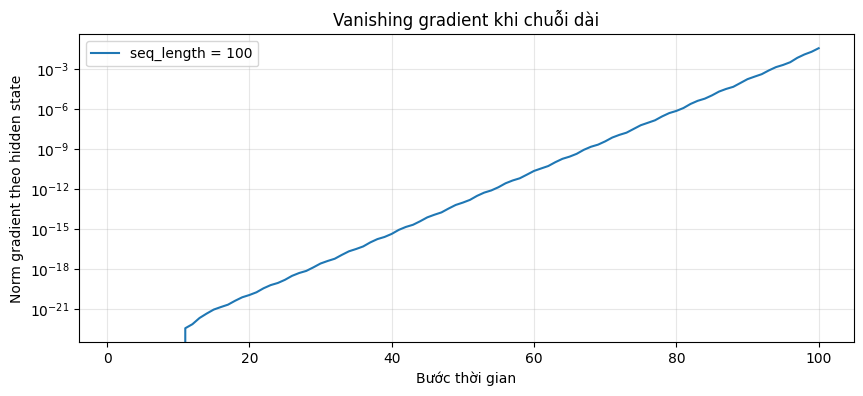

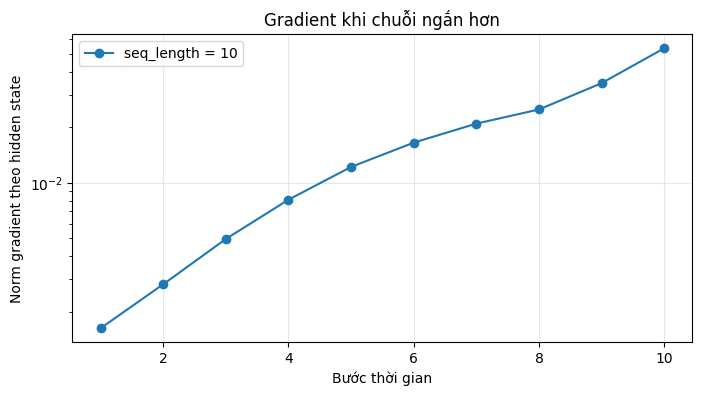


NHẬN XÉT BÀI 2:
Với seq_length=100, gradient ở các bước đầu chuỗi nhỏ hơn rất nhiều so với các bước cuối.
Điều này cho thấy thông tin từ xa bị yếu dần khi lan truyền ngược qua nhiều bước thời gian.
Với seq_length=10, khoảng cách giữa đầu và cuối chuỗi nhỏ hơn nên hiện tượng vanishing gradient nhẹ hơn.


In [ ]:
# Bài tập 2 — Quan sát hiện tượng vanishing gradient

torch.manual_seed(42)
np.random.seed(42)

def tao_du_lieu_sin_gradient(time_steps=500, seq_length=100):
    x_g = np.linspace(0, 50, time_steps)
    data_g = np.sin(x_g) + 0.05 * np.random.randn(time_steps)
    data_g = (data_g - data_g.min()) / (data_g.max() - data_g.min())
    data_g = torch.tensor(data_g, dtype=torch.float32).unsqueeze(1)

    X_g, y_g = [], []
    for i in range(len(data_g) - seq_length):
        X_g.append(data_g[i:i + seq_length])
        y_g.append(data_g[i + seq_length])
    return torch.stack(X_g), torch.stack(y_g)

class RNNCellTheoDoiGradient(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn_cell = nn.RNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size)
        hidden_states = []

        for t_step in range(seq_len):
            h = self.rnn_cell(x[:, t_step, :], h)
            h.retain_grad()
            hidden_states.append(h)

        out = self.fc(h)
        return out, hidden_states

def tinh_gradient_theo_thoi_gian(seq_length):
    X_g, y_g = tao_du_lieu_sin_gradient(time_steps=500, seq_length=seq_length)

    # Lấy một batch cố định để quan sát gradient.
    X_batch = X_g[:32]
    y_batch = y_g[:32]

    model_g = RNNCellTheoDoiGradient(input_size=1, hidden_size=8, output_size=1)
    criterion_g = nn.MSELoss()

    pred_g, hidden_states = model_g(X_batch)
    loss_g = criterion_g(pred_g, y_batch)
    loss_g.backward()

    grad_norms = np.array([
        h.grad.norm().item() if h.grad is not None else 0.0
        for h in hidden_states
    ])

    weight_hh_grad_norm = model_g.rnn_cell.weight_hh.grad.norm().item()

    print(f'\nseq_length = {seq_length}')
    print(f'Loss: {loss_g.item():.6f}')
    print(f'Norm gradient của weight_hh: {weight_hh_grad_norm:.6f}')
    print(f'Gradient đầu chuỗi : {grad_norms[0]:.10f}')
    print(f'Gradient giữa chuỗi: {grad_norms[len(grad_norms)//2]:.10f}')
    print(f'Gradient cuối chuỗi: {grad_norms[-1]:.10f}')

    return grad_norms

grad_100 = tinh_gradient_theo_thoi_gian(seq_length=100)
grad_10 = tinh_gradient_theo_thoi_gian(seq_length=10)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(grad_100) + 1), grad_100, label='seq_length = 100')
plt.xlabel('Bước thời gian')
plt.ylabel('Norm gradient theo hidden state')
plt.title('Vanishing gradient khi chuỗi dài')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(grad_10) + 1), grad_10, marker='o', label='seq_length = 10')
plt.xlabel('Bước thời gian')
plt.ylabel('Norm gradient theo hidden state')
plt.title('Gradient khi chuỗi ngắn hơn')
plt.legend()
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

print('\nNHẬN XÉT BÀI 2:')
print('Với seq_length=100, gradient ở các bước đầu chuỗi nhỏ hơn rất nhiều so với các bước cuối.')
print('Điều này cho thấy thông tin từ xa bị yếu dần khi lan truyền ngược qua nhiều bước thời gian.')
print('Với seq_length=10, khoảng cách giữa đầu và cuối chuỗi nhỏ hơn nên hiện tượng vanishing gradient nhẹ hơn.')


,model,one_step_mse,so_tham_so
0,RNN,0.002544,481
1,ANN,0.002931,241
2,Baseline naive,0.005995,0


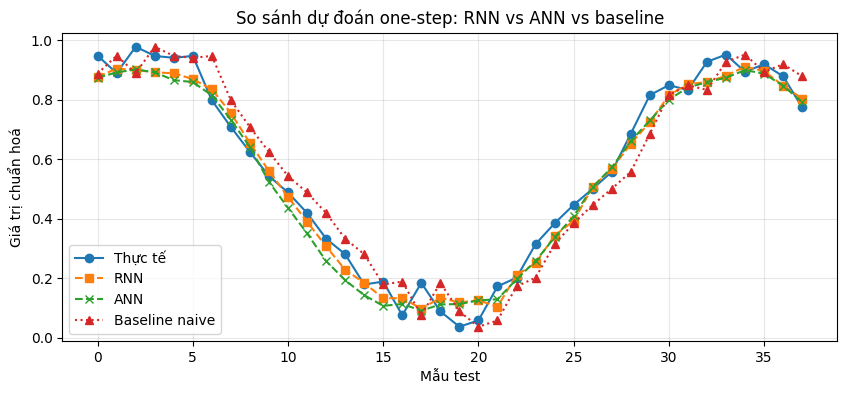

NHẬN XÉT BÀI 3:
Model có MSE thấp nhất trong lần chạy này là: RNN.
RNN xử lý input theo thứ tự thời gian và dùng trạng thái ẩn để ghi nhớ thông tin trước đó.
ANN flatten toàn bộ cửa sổ 10 giá trị thành một vector nên không có cơ chế hồi quy theo thời gian.
Baseline naive không học tham số, chỉ lấy giá trị cuối cùng trong cửa sổ làm dự đoán.
Nếu RNN/ANN có MSE thấp hơn baseline naive thì mô hình đã học được thêm quy luật của chuỗi thay vì chỉ sao chép giá trị gần nhất.


In [ ]:
# Bài tập 3 — So sánh RNN, ANN và baseline naive trên dữ liệu sóng sin của bài lab

torch.manual_seed(42)
np.random.seed(42)

# Tạo lại dữ liệu sóng sin như bài lab.
time_steps_cmp = 200
x_cmp = np.linspace(0, 40, time_steps_cmp)
data_cmp = np.sin(x_cmp) + 0.1 * np.random.randn(time_steps_cmp)
data_cmp = (data_cmp - data_cmp.min()) / (data_cmp.max() - data_cmp.min())
data_cmp = torch.FloatTensor(data_cmp).unsqueeze(1)

seq_length_cmp = 10
X_cmp, y_cmp = create_sequences(data_cmp, seq_length_cmp)

train_size_cmp = int(0.8 * len(X_cmp))
X_train_cmp, X_test_cmp = X_cmp[:train_size_cmp], X_cmp[train_size_cmp:]
y_train_cmp, y_test_cmp = y_cmp[:train_size_cmp], y_cmp[train_size_cmp:]

train_loader_cmp = DataLoader(
    TensorDataset(X_train_cmp, y_train_cmp),
    batch_size=16,
    shuffle=True
)

class RNNSoSanh(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class ANNSoSanh(nn.Module):
    def __init__(self, input_size=10, hidden_size=20, output_size=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

def dem_tham_so(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model_cmp(model_cmp, num_epochs=100, lr=1e-2):
    criterion_cmp = nn.MSELoss()
    optimizer_cmp = torch.optim.Adam(model_cmp.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model_cmp.train()
        for X_batch, y_batch in train_loader_cmp:
            optimizer_cmp.zero_grad()
            pred = model_cmp(X_batch)
            loss = criterion_cmp(pred, y_batch)
            loss.backward()
            optimizer_cmp.step()

    return model_cmp

rnn_cmp = train_model_cmp(RNNSoSanh(), num_epochs=80)
ann_cmp = train_model_cmp(ANNSoSanh(input_size=seq_length_cmp), num_epochs=80)

with torch.no_grad():
    pred_rnn_cmp = rnn_cmp(X_test_cmp).squeeze().numpy()
    pred_ann_cmp = ann_cmp(X_test_cmp).squeeze().numpy()
    truth_cmp = y_test_cmp.squeeze().numpy()
    pred_naive_cmp = X_test_cmp[:, -1, 0].numpy()

mse_rnn_cmp = np.mean((pred_rnn_cmp - truth_cmp) ** 2)
mse_ann_cmp = np.mean((pred_ann_cmp - truth_cmp) ** 2)
mse_naive_cmp = np.mean((pred_naive_cmp - truth_cmp) ** 2)

comparison_df = pd.DataFrame([
    {
        'model': 'RNN',
        'one_step_mse': mse_rnn_cmp,
        'so_tham_so': dem_tham_so(rnn_cmp)
    },
    {
        'model': 'ANN',
        'one_step_mse': mse_ann_cmp,
        'so_tham_so': dem_tham_so(ann_cmp)
    },
    {
        'model': 'Baseline naive',
        'one_step_mse': mse_naive_cmp,
        'so_tham_so': 0
    }
])

display(comparison_df)

plt.figure(figsize=(10, 4))
plt.plot(truth_cmp, 'o-', label='Thực tế')
plt.plot(pred_rnn_cmp, 's--', label='RNN')
plt.plot(pred_ann_cmp, 'x--', label='ANN')
plt.plot(pred_naive_cmp, '^:', label='Baseline naive')
plt.xlabel('Mẫu test')
plt.ylabel('Giá trị chuẩn hoá')
plt.title('So sánh dự đoán one-step: RNN vs ANN vs baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_model_name = comparison_df.loc[comparison_df['one_step_mse'].idxmin(), 'model']

print('NHẬN XÉT BÀI 3:')
print(f'Model có MSE thấp nhất trong lần chạy này là: {best_model_name}.')
print('RNN xử lý input theo thứ tự thời gian và dùng trạng thái ẩn để ghi nhớ thông tin trước đó.')
print('ANN flatten toàn bộ cửa sổ 10 giá trị thành một vector nên không có cơ chế hồi quy theo thời gian.')
print('Baseline naive không học tham số, chỉ lấy giá trị cuối cùng trong cửa sổ làm dự đoán.')
print('Nếu RNN/ANN có MSE thấp hơn baseline naive thì mô hình đã học được thêm quy luật của chuỗi thay vì chỉ sao chép giá trị gần nhất.')
